<a href="https://colab.research.google.com/github/Carlos-PC05/FinalProjectCS-362/blob/main/FinalReport_SP26_RV_PC_MASTERFILE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----

## Reminders before submitting any phase

### Please delete this section/these reminders BEFORE your final final submission at the end of the semester

* **TECHNIQUES FROM CLASS**:  Be sure to rely on your techniques from class when working on your project.  Points wil  be deducted if you skip over relevant technqiques that should  be considered.  Examples:
    * Correlation coefficents should be given for scatterplots;
    * If you give a p-value (which you should at some point), you should interpret it and also be sure to include the null and alternative hypotheses.
    * If you're doing a regression, be sure to desicuss the properties of the residual plot.
    * GridSearchCV should be used to help hypertune your parameters.
    * etc.
* **FLOW**: Eventually, you need to have FLOW in your project, where one section flows into the next.
    * So each section should have an opening sentence for readibility introducing the point of the section.
    * Also, at the end of the section, you must include a discussion of what question you plan to ask next or where your analysis is heading.
    * Your goal is to create a *READABLE*, professional writeup.
* **AUDIENCE**:   Your audience is a company, not an educator.  So pretend you are a consultant for a company and presenting results to them.  Be professional.  Include any background that the reader might need to know to understand the question.
* **GRAPHS**:  We love them.  Be sure to xplain what you learn from the graph AFTER the graph picture.
    * Each graph needs a title, y axis labels, and x axis labels, and legends if necessary.   
* **TABLE OF CONTENTS:**  You need an organized table of contents showing all your subsections and helping the reader read through your document.
* There should be **no crappy "text"** printed before each picture.
    * Add a semicolon to the last line int he code cell to prevent this.
* In each code cell, **there must be a code comment** explaining what is going on in the code cell.
    * NOOOOOOO results should be discussed in the hashtag areas
    * Example of a good code comment:  #In this code cell, we build a line graph of the number of reservations across time.
* If there is **anything special going on in your code cell, that should be documented and explained with code comments**  and possibly in the discussion before the code cell, if appropriate.
    * For example, if you are filtering on a special condition (like where tuition > 0 for some reason) then explain why.
* **Long Code:**  Coders don't like to scroll right!
    * If you have long code that extends to the right so that I'd have to scroll to see it, then just hit enter after a comma and the code will be placed indented on the next line for you.   
* **"Significant"** ->  Only use this word if you have done a hypothesis test... "There is a **significant** difference between the average launch angle in 2022 and in 2015."
    * If not using a hypothesis test/p-value, then use a synonym like  **striking**.
    * So know that the word "significant"  requires statistical evidence.  
* **Correlation does NOT imply causation** so don't accidentally use lingo that suggests that "variable X" is CAUSING some change in varaiable Y:
    * SHOULD NOT SAY:  
        * X is impacting Y
        * X causes Y
        * X contributes to Y
        * X influences to Y
        * X leads to Y
        * X increases Y
        * etc
    * Instead, just keep your lingo speculative and then you can make guesses:
      * It is possible that we see this effect because of XXX.
      * Perhaps this makes sense because XXX.

---

In [39]:
pip install kagglehub

In [40]:
# imports go here
import os

#For reading the dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr  #to calculate the correlation coefficient r

#For the regression model
from sklearn.linear_model import LinearRegression
#for splitting
from sklearn.model_selection import train_test_split


---
#### CS 362 - Machine Learning - Final Project - SP26

---

# Title (Give a title, based on your topic. Also be sure to rename the file with your initials.)

### By: Carlos Parra Camacho and Raymond Vargas Pérez


---

## 1. Introduction

For this project, our group explored... (This section will be finished at a later date and can be skipped at this time.)

When you do write it: I expect 2-3 paragraphs, more if needed.

---

## 2. Data

A direct link to the data can be found at the following website.
https://www.kaggle.com/datasets/jboysen/mri-and-alzheimers

**Dr. Note to students - Fill in the details of how/when the data was obtained and delete this bolded comment. Example:** According the website, the data was collected via "telephone interviews conducted February 5-8, 2015 among a national sample of 1,003 adults, 18 years of age or older, living in the continental United States."   We believe the data is legitimate because XXX

**Dr. Note to students - Fill in the details of the code cell below for your project.  Be sure to read the comments in the cell for understanding, and then delete this comment.**

In [41]:
#In this cell, we load the data and rename columns appropriately
path = kagglehub.dataset_download("jboysen/mri-and-alzheimers")

# Load the CSV file directly using pandas
csv_file = os.path.join(path, "oasis_cross-sectional.csv")  # This is the main data file
mri_df = pd.read_csv(csv_file)

# Display the loaded data
mri_df.head()

Using Colab cache for faster access to the 'mri-and-alzheimers' dataset.


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [42]:
# get the info of the data

####### DR comments - delete when done#################################
# Be sure to do what is needed to change the types of the data if necessary
# There could be code clean up here - just document what you are doing and why

mri_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    object 
 1   M/F     436 non-null    object 
 2   Hand    436 non-null    object 
 3   Age     436 non-null    int64  
 4   Educ    235 non-null    float64
 5   SES     216 non-null    float64
 6   MMSE    235 non-null    float64
 7   CDR     235 non-null    float64
 8   eTIV    436 non-null    int64  
 9   nWBV    436 non-null    float64
 10  ASF     436 non-null    float64
 11  Delay   20 non-null     float64
dtypes: float64(7), int64(2), object(3)
memory usage: 41.0+ KB


### 2.1 Summary of Variables within the mri_df Table

The mri_df table has 12 columns/variables and 436 rows.  All variables are explained in this section, including their descriptions, their units, their types, and some descriptive statistics.

#### A. CATEGORICAL VARIABLES

* **M/F** – M if is a male, F if is a female
    * Number of missing values: 0
    * Contains 2 distinct values:
        * List the values.
        - M -> male
        - F -> female

* **Hand** – if the person is right or left handed
    * Number of missing values: 0
    * Contains 2 distinct values:
        * List the values.  
        - R -> right-handed
        - L -> left-handed
#### B. QUANTITATIVE  DISCRETE VARIABLES

* **Age** – the age of the person
    * Number of missing values: 0
    * Units: years
    * max value: 96
    * min value: 18
    * average value: 51.357798165137616

* **Educ** – Educational level
    * Number of missing values: 201
    * max value: 5
    * min value: 1
    * average value: 3.178723404255319

* **SES** – socioeconomic status
    * Number of missing values: 220
    * max value: 5
    * min value: 1
    * average value: 2.490740740740741

* **MMSE** – Mini Mental State Examination
    * Number of missing values: 201
    * max value: 30
    * min value: 14
    * average value: 27.06382978723404

* **CDR** – Clinical Dementia Rating (0 = None, 0.5 = Very Mild, 1 = Mild, 2 = Moderate).
    * Number of missing values: 201
    * max value: 2
    * min value: 0
    * average value: 0.2851063829787234

#### C. QUANTITATIVE CONTINUOUS VARIABLES

* **eTIV** – Estimated Total Intracranial Volume (mm^3)
    * Number of missing values: 0
    * max value: 1992
    * min value: 1123
    * average value: 1481.9197247706422

* **nWBV** – Normalize Whole Brain Volume: Normalized Whole Brain Volume (the proportion of all voxels identified as grey or white matter).
    * Number of missing values: 0
    * max value: 0.893
    * min value: 0.644
    * average value: 0.7916697247706422

* **ASF** – Atlas Scalating Factor: This is a computed scaling factor used to transform a subject's native brain image into a standard "atlas" space (typically the Talairach atlas).
   * Number of missing values: 0
   * max value: 1.563
   * min value: 0.881
   * average value: 1.1988944954128438

* **Delay** - This column is found in the cross-sectional data subset. It represents the number of days between the initial MRI scan and a subsequent "reliability" scan.
   * Number of missing values: 0
   * max value: 1.563
   * min value: 0.881
   * average value: 1.1988944954128438

### 2.2 Code used to Summarize Variables

In this section we include the code used to describe the variables in the previous section.

In [43]:
#Showing the number of distinct values in each column to understand the data better
for col in mri_df.columns:
    print(f"{col}: {mri_df[col].nunique()} distinct values")


ID: 436 distinct values
M/F: 2 distinct values
Hand: 1 distinct values
Age: 73 distinct values
Educ: 5 distinct values
SES: 5 distinct values
MMSE: 17 distinct values
CDR: 4 distinct values
eTIV: 312 distinct values
nWBV: 182 distinct values
ASF: 282 distinct values
Delay: 14 distinct values


In [44]:
#Get the min, max, avergae, and number of missing values in the Age column
max = mri_df['Age'].max()
min = mri_df['Age'].min()
mean = mri_df['Age'].mean()

print(f"Max Age: {max}")
print(f"Min Age: {min}")
print(f"Mean Age: {mean}")

# Count null values in the 'Age' column
missing = mri_df['Age'].isna().sum()
print(f"Number of missing values in Age: {missing}")

Max Age: 96
Min Age: 18
Mean Age: 51.357798165137616
Number of missing values in Age: 0


In [45]:
#Get the min, max, avergae, and number of missing values in the Educ column
max = mri_df['Educ'].max()
min = mri_df['Educ'].min()
mean = mri_df['Educ'].mean()

print(f"Max Educ: {max}")
print(f"Min Educ: {min}")
print(f"Mean Educ: {mean}")

# Count null values in the 'Educ' column
missing = mri_df['Educ'].isna().sum()
print(f"Number of missing values in Educ: {missing}")

Max Educ: 5.0
Min Educ: 1.0
Mean Educ: 3.178723404255319
Number of missing values in Educ: 201


In [46]:
#Get the min, max, avergae, and number of missing values in the SES column
max = mri_df['SES'].max()
min = mri_df['SES'].min()
mean = mri_df['SES'].mean()

print(f"Max SES: {max}")
print(f"Min SES: {min}")
print(f"Mean SES: {mean}")

# Count null values in the 'SES' column
missing = mri_df['SES'].isna().sum()
print(f"Number of missing values in SES: {missing}")

Max SES: 5.0
Min SES: 1.0
Mean SES: 2.490740740740741
Number of missing values in SES: 220


In [47]:
#Get the min, max, avergae, and number of missing values in the MMSE column
max = mri_df['MMSE'].max()
min = mri_df['MMSE'].min()
mean = mri_df['MMSE'].mean()

print(f"Max MMSE: {max}")
print(f"Min MMSE: {min}")
print(f"Mean MMSE: {mean}")

# Count null values in the 'MMSE' column
missing = mri_df['MMSE'].isna().sum()
print(f"Number of missing values in MMSE: {missing}")

Max MMSE: 30.0
Min MMSE: 14.0
Mean MMSE: 27.06382978723404
Number of missing values in MMSE: 201


In [48]:
#Get the min, max, avergae, and number of missing values in the CDR column
max = mri_df['CDR'].max()
min = mri_df['CDR'].min()
mean = mri_df['CDR'].mean()

print(f"Max CDR: {max}")
print(f"Min CDR: {min}")
print(f"Mean CDR: {mean}")

# Count null values in the 'CDR' column
missing = mri_df['CDR'].isna().sum()
print(f"Number of missing values in CDR: {missing}")

Max CDR: 2.0
Min CDR: 0.0
Mean CDR: 0.2851063829787234
Number of missing values in CDR: 201


In [49]:
#Get the min, max, avergae, and number of missing values in the eTIV column
max = mri_df['eTIV'].max()
min = mri_df['eTIV'].min()
mean = mri_df['eTIV'].mean()

print(f"Max eTIV: {max}")
print(f"Min eTIV: {min}")
print(f"Mean eTIV: {mean}")

# Count null values in the 'eTIV' column
missing = mri_df['eTIV'].isna().sum()
print(f"Number of missing values in eTIV: {missing}")

Max eTIV: 1992
Min eTIV: 1123
Mean eTIV: 1481.9197247706422
Number of missing values in eTIV: 0


In [50]:
#Get the min, max, avergae, and number of missing values in the nWBV column
max = mri_df['nWBV'].max()
min = mri_df['nWBV'].min()
mean = mri_df['nWBV'].mean()

print(f"Max nWBV: {max}")
print(f"Min nWBV: {min}")
print(f"Mean nWBV: {mean}")

# Count null values in the 'nWBV' column
missing = mri_df['nWBV'].isna().sum()
print(f"Number of missing values in nWBV: {missing}")

Max nWBV: 0.893
Min nWBV: 0.644
Mean nWBV: 0.7916697247706422
Number of missing values in nWBV: 0


In [51]:
#Get the min, max, avergae, and number of missing values in the ASF column
max = mri_df['ASF'].max()
min = mri_df['ASF'].min()
mean = mri_df['ASF'].mean()

print(f"Max ASF: {max}")
print(f"Min ASF: {min}")
print(f"Mean ASF: {mean}")

# Count null values in the 'nWBV' column
missing = mri_df['ASF'].isna().sum()
print(f"Number of missing values in ASF: {missing}")

Max ASF: 1.563
Min ASF: 0.881
Mean ASF: 1.1988944954128438
Number of missing values in ASF: 0


In [52]:
#Get the min, max, avergae, and number of missing values in the Delay column
max = mri_df['Delay'].max()
min = mri_df['Delay'].min()
mean = mri_df['Delay'].mean()

print(f"Max Delay: {max}")
print(f"Min Delay: {min}")
print(f"Mean Delay: {mean}")

# Count null values in the 'nWBV' column
missing = mri_df['Delay'].isna().sum()
print(f"Number of missing values in Delay: {missing}")

Max Delay: 89.0
Min Delay: 1.0
Mean Delay: 20.55
Number of missing values in Delay: 416


---

## 3. Split into Train/Test

First of all we give the dataframe columns a conventional name

In [53]:
mri_df = mri_df.rename(columns={
    'ID' : 'id',
    'M/F' : 'gender',
    'Hand' : 'dominating_hand',
    'Age' : 'age',
    'Educ' : 'education_level',
    'SES' : 'socioeconomic_status',
    'MMSE' : 'mini_mental_state_examination',
    'CDR' : 'clinical_dementia_rating',
    'eTIV' : 'estimated_total_intracranial_volume',
    'nWBV' : 'normalized_whole_brain_volume',
    'ASF' : 'atlas_scaling_factor',
    'Delay' : 'delay'
})
mri_df

,id,gender,dominating_hand,age,education_level,socioeconomic_status,mini_mental_state_examination,clinical_dementia_rating,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
431,OAS1_0285_MR2,M,R,20,NaN,NaN,NaN,NaN,1469,0.847,1.195,2.0
432,OAS1_0353_MR2,M,R,22,NaN,NaN,NaN,NaN,1684,0.790,1.042,40.0
433,OAS1_0368_MR2,M,R,22,NaN,NaN,NaN,NaN,1580,0.856,1.111,89.0
434,OAS1_0379_MR2,F,R,20,NaN,NaN,NaN,NaN,1262,0.861,1.390,2.0


We now split the data into a training and a testing set for upcoming analysis.

In [54]:
#Set a seed for reproducibility
SEED = 23

In [55]:
# Dropping non-predictor features (including the targets)
X = mri_df.drop(columns = ['id', 'mini_mental_state_examination', 'clinical_dementia_rating'])

y_reg = mri_df["mini_mental_state_examination"]   # regression target
y_clf = mri_df["clinical_dementia_rating"]         # classification target

# One split, same random state keeps rows consistent
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.20, random_state=SEED)
_, _, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.20, random_state=SEED)

X_train.shape, X_test.shape, y_reg_train.shape, y_reg_test.shape, y_clf_train.shape, y_clf_test.shape

((348, 9), (88, 9), (348,), (88,), (348,), (88,))

In [56]:
# Unite the training data into a dataframe for the EDA (classification)

mri_train_clf_df = pd.concat([X_train, y_clf_train], axis=1)
mri_train_clf_df.head()


,gender,dominating_hand,age,education_level,socioeconomic_status,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,delay,clinical_dementia_rating
82,F,R,21,NaN,NaN,1507,0.845,1.165,NaN,NaN
315,F,R,43,NaN,NaN,1227,0.858,1.430,NaN,NaN
419,M,R,29,NaN,NaN,1501,0.835,1.169,64.0,NaN
179,F,R,89,3.0,3.0,1154,0.747,1.521,NaN,0.0
188,F,R,78,5.0,1.0,1243,0.747,1.412,NaN,0.0


In [57]:
# Unite the training data into a dataframe for the EDA (regression)

mri_train_reg_df = pd.concat([X_train, y_reg_train], axis=1)
mri_train_reg_df.head()

,gender,dominating_hand,age,education_level,socioeconomic_status,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,delay,mini_mental_state_examination
82,F,R,21,NaN,NaN,1507,0.845,1.165,NaN,NaN
315,F,R,43,NaN,NaN,1227,0.858,1.430,NaN,NaN
419,M,R,29,NaN,NaN,1501,0.835,1.169,64.0,NaN
179,F,R,89,3.0,3.0,1154,0.747,1.521,NaN,29.0
188,F,R,78,5.0,1.0,1243,0.747,1.412,NaN,30.0


In [58]:
# Unite the testing data into a dataframe for the EDA (classification)

mri_test_clf_df = pd.concat([X_test, y_clf_test], axis=1)
mri_test_clf_df.head()

,gender,dominating_hand,age,education_level,socioeconomic_status,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,delay,clinical_dementia_rating
195,F,R,48,NaN,NaN,1332,0.801,1.318,NaN,NaN
145,F,R,86,4.0,3.0,1293,0.756,1.357,NaN,0.0
222,F,R,80,4.0,2.0,1341,0.737,1.309,NaN,0.0
401,F,R,52,3.0,3.0,1431,0.814,1.226,NaN,0.0
414,M,R,61,5.0,2.0,1637,0.780,1.072,NaN,0.0


In [59]:
# Unite the testing data into a dataframe for the EDA (regression)

mri_test_reg_df = pd.concat([X_test, y_reg_test], axis=1)
mri_test_reg_df.head()

,gender,dominating_hand,age,education_level,socioeconomic_status,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,delay,mini_mental_state_examination
195,F,R,48,NaN,NaN,1332,0.801,1.318,NaN,NaN
145,F,R,86,4.0,3.0,1293,0.756,1.357,NaN,30.0
222,F,R,80,4.0,2.0,1341,0.737,1.309,NaN,29.0
401,F,R,52,3.0,3.0,1431,0.814,1.226,NaN,30.0
414,M,R,61,5.0,2.0,1637,0.780,1.072,NaN,30.0


## 4. Initial EDA

**Students, in this section, ask some interesting questions about your (training) data in order to start learning about it.  Likely, the xxx_train_df dataframe will be the dataframe you user here.**

Prior to building any models, we begin our analysis by performing a exploratory data analysis on the **training data.**

We begin by giving a high-level look at the training data, it's shape, data types and missing values to make sure the split looks as expected and to flag any issues before diving deeper.

**As you learn about your data, create subsections with sensible titles to keep your analysis organized.  So what are you trying to learn about in this section? Include an introductory senrtence and a discussion after each graph/test/etc.  Remember that your eventual goal is flow and your file must be easily readable.****

### 4.1 Overview the training data

In [60]:
# Quick overview of the training set (classifcation)
print(f"Training set shape : {mri_train_clf_df.shape}")
print()
mri_train_clf_df.info()

Training set shape : (348, 10)

<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 82 to 83
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   gender                               348 non-null    object 
 1   dominating_hand                      348 non-null    object 
 2   age                                  348 non-null    int64  
 3   education_level                      184 non-null    float64
 4   socioeconomic_status                 171 non-null    float64
 5   estimated_total_intracranial_volume  348 non-null    int64  
 6   normalized_whole_brain_volume        348 non-null    float64
 7   atlas_scaling_factor                 348 non-null    float64
 8   delay                                20 non-null     float64
 9   clinical_dementia_rating             184 non-null    float64
dtypes: float64(6), int64(2), object(2)
memory usage: 29.9+ KB


In [61]:
# Quick overview of the training set (regression)
print(f"Training set shape : {mri_train_reg_df.shape}")
print()
mri_train_reg_df.info()

Training set shape : (348, 10)

<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 82 to 83
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   gender                               348 non-null    object 
 1   dominating_hand                      348 non-null    object 
 2   age                                  348 non-null    int64  
 3   education_level                      184 non-null    float64
 4   socioeconomic_status                 171 non-null    float64
 5   estimated_total_intracranial_volume  348 non-null    int64  
 6   normalized_whole_brain_volume        348 non-null    float64
 7   atlas_scaling_factor                 348 non-null    float64
 8   delay                                20 non-null     float64
 9   mini_mental_state_examination        184 non-null    float64
dtypes: float64(6), int64(2), object(2)
memory usage: 29.9+ KB


In [62]:
# Missing values in the training set (classifcation)
missing_train_clf = mri_train_clf_df.isnull().sum()
print("Missing values per column:")
print(missing_train_clf[missing_train_clf > 0])

Missing values per column:
education_level             164
socioeconomic_status        177
delay                       328
clinical_dementia_rating    164
dtype: int64


In [63]:
# Missing values in the training set (regression)
missing_train_reg = mri_train_reg_df.isnull().sum()
print("Missing values per column:")
print(missing_train_reg[missing_train_reg > 0])

Missing values per column:
education_level                  164
socioeconomic_status             177
delay                            328
mini_mental_state_examination    164
dtype: int64


Here we have a close look at the columns from the training dataset that have missing values and how many they have.

### 4.2 Distribution of the classification target variable (CDR)
Our classification target variable is **CDR** (Clinical Dementia Rating), a widely-used scale for staging dementia severity. Before examining any predictors, we want to understand the distribution of CDR values in the training set to check for class imbalance and to understand what we are trying to predict.

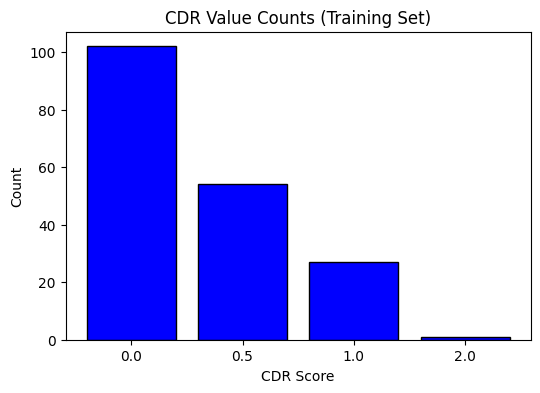

CDR value distribution:
clinical_dementia_rating
0.0    102
0.5     54
1.0     27
2.0      1
Name: count, dtype: int64


In [64]:
# Distribution of CDR in the training set
plt.figure(figsize=(6, 4))

# Count plot
cdr_counts = mri_train_clf_df['clinical_dementia_rating'].value_counts().sort_index()
plt.bar(cdr_counts.index.astype(str), cdr_counts.values, color='blue', edgecolor='black')
plt.title('CDR Value Counts (Training Set)')
plt.xlabel('CDR Score')
plt.ylabel('Count')

plt.show()

print("CDR value distribution:")
print(cdr_counts)

As we can see, in the training dataset we have 102 nondement people, 54 with a very mild dementia level, 27 with mild and just 1 with moderate level.

### 4.3 Demographic Distribution: age and sex

We next examine the demographic composition of the training set. Understanding the age range and sex distribution helps contextualize the clinical findings, since Alzheimer's disease prevalence increases with age and shows some sex-based differences in the literature.

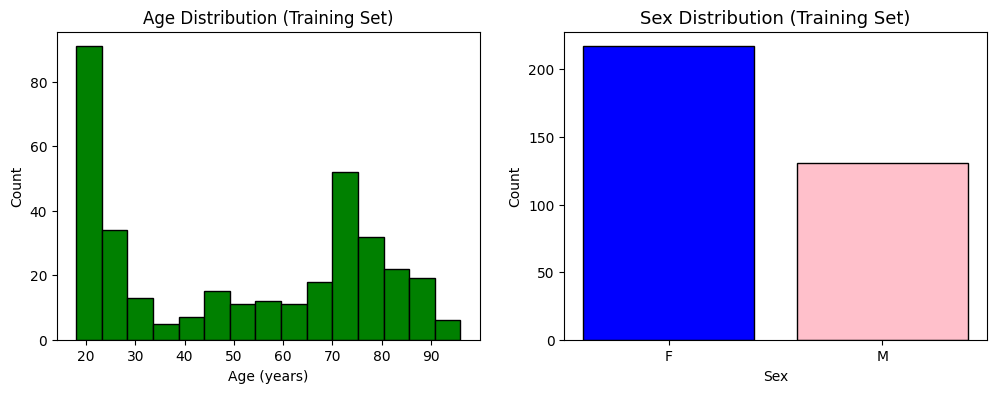

Age: min=18, max=96, mean=51.2, std=25.6

Sex counts:
gender
F    217
M    131
Name: count, dtype: int64


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(mri_train_clf_df['age'], bins=15, color='green', edgecolor='black')
axes[0].set_title('Age Distribution (Training Set)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

# Sex distribution
sex_counts = mri_train_clf_df['gender'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values,
            color=['blue', 'pink'], edgecolor='black')
axes[1].set_title('Sex Distribution (Training Set)', fontsize=13)
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')

plt.show()

print(f"Age: min={mri_train_clf_df['age'].min()}, max={mri_train_clf_df['age'].max()}, "
      f"mean={mri_train_clf_df['age'].mean():.1f}, std={mri_train_clf_df['age'].std():.1f}")
print(f"\nSex counts:\n{sex_counts}")

As we can see, in the training dataset, ages are distributed in such a way that there is a higher proportion at the extremes—young people and older people. As for gender, there is a clear majority of women in our training datase

### 4.4 Socioeconomic Status (SES) and Education (Educ) by CDR

Socioeconomic status and education level are known protective factors against cognitive decline. Here we examine whether subjects with different CDR ratings differ in their SES and education levels within our training data.

Whis will answer the question of "Does the socioeconomic status and educational level have a relationship with the clinical dementia rating?"

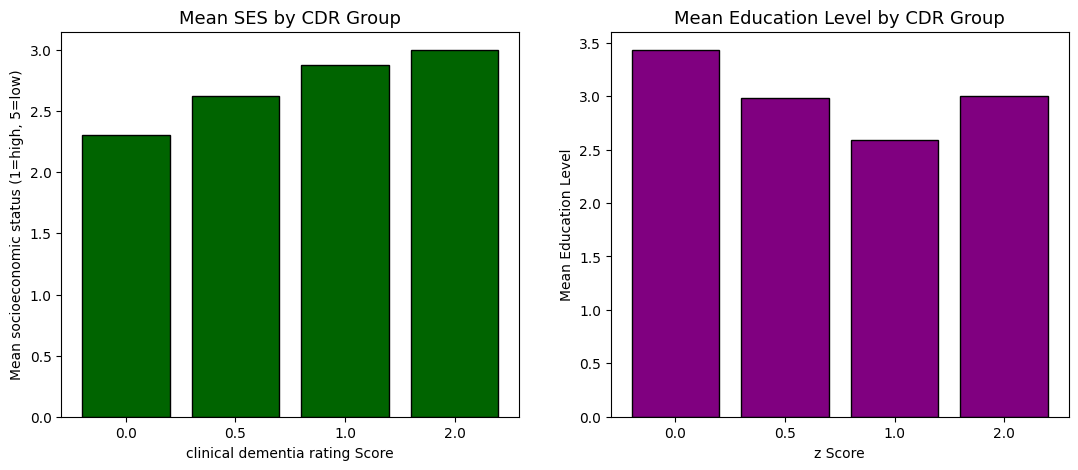

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SES by CDR
cdr_group = mri_train_clf_df.dropna(subset=['socioeconomic_status']).groupby('clinical_dementia_rating')['socioeconomic_status'].mean()
axes[0].bar(cdr_group.index.astype(str), cdr_group.values, color='darkGreen', edgecolor='black')
axes[0].set_title('Mean SES by CDR Group', fontsize=13)
axes[0].set_xlabel('clinical dementia rating Score')
axes[0].set_ylabel('Mean socioeconomic status (1=high, 5=low)')

# Educ by CDR
educ_group = mri_train_clf_df.groupby('clinical_dementia_rating')['education_level'].mean()
axes[1].bar(educ_group.index.astype(str), educ_group.values, color='purple', edgecolor='black')
axes[1].set_title('Mean Education Level by CDR Group', fontsize=13)
axes[1].set_xlabel('z Score')
axes[1].set_ylabel('Mean Education Level')

plt.show()

as we can see, socioeconomic status tends to be lowe as the clinical dementia rating is higher.
However, the education level mean when the clinical dementia rating is 0 is higher than the rest but as the CDR increases, there is not much difference in the education level.

### 4.5 Distribution of the Regression Target Variable (MMSE)

Our regression target variable is **MMSE** (Mini Mental State Examination), a widely-used 30-point cognitive screening test. Higher scores indicate better cognitive function (27–30 = normal, 21–26 = mild impairment, 10–20 = moderate, <10 = severe). Before comparing MMSE against our predictors, we first examine how scores are distributed in the training set.

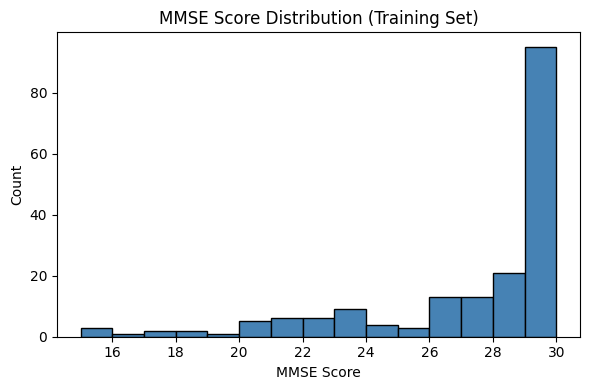

In [67]:
# Distribution of MMSE in the training set
plt.figure(figsize=(6, 4))

mmse_counts = mri_train_reg_df['mini_mental_state_examination'].dropna()
plt.hist(mmse_counts, bins=15, color='steelblue', edgecolor='black')
plt.title('MMSE Score Distribution (Training Set)')
plt.xlabel('MMSE Score')
plt.ylabel('Count')
plt.tight_layout();

In [68]:
#Getting a direct count of the data we see above
print(mri_train_reg_df['mini_mental_state_examination'].value_counts().sort_index())

mini_mental_state_examination
15.0     3
16.0     1
17.0     2
18.0     2
19.0     1
20.0     5
21.0     6
22.0     6
23.0     9
24.0     4
25.0     3
26.0    13
27.0    13
28.0    21
29.0    41
30.0    54
Name: count, dtype: int64


The training set shows that most subjects score in the higher range of the MMSE scale, indicating that the majority of participants are cognitively normal or only mildly impaired. The distribution is left-skewed, with relatively few subjects falling in the moderate impairment range. This concentration of scores at the higher end is worth noting, as it may affect the performance of the regression model on lower-scoring cases.

### 4.6 Demographic Distribution: Age and Sex by MMSE

We next examine how age and sex relate to MMSE scores in the training set. As with CDR, we expect older subjects to show lower cognitive scores on average, and we check whether there is a meaningful difference in MMSE between male and female participants.

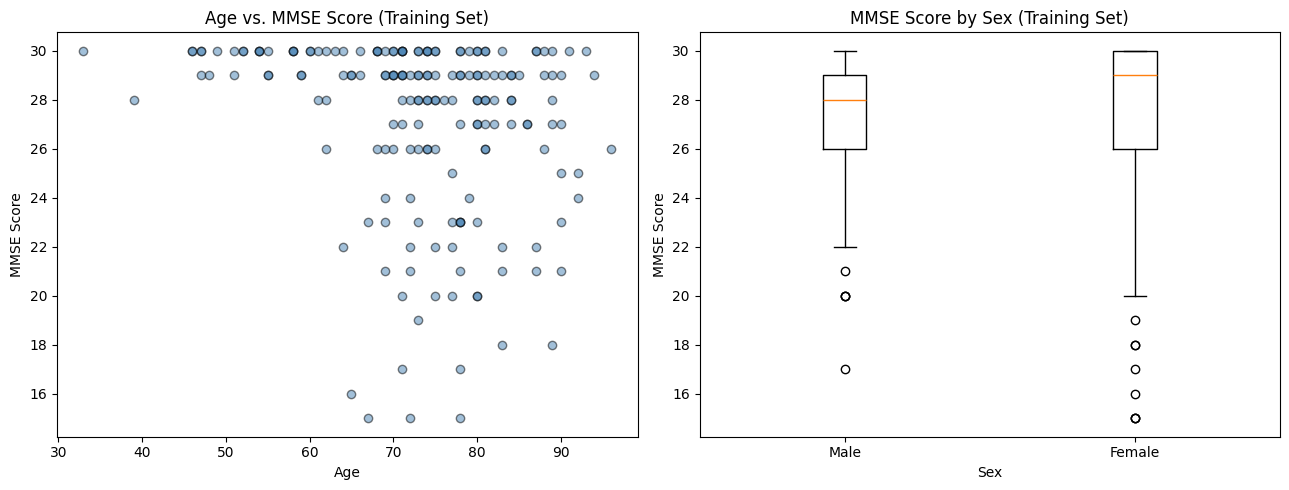

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age vs MMSE scatter plot
axes[0].scatter(
    mri_train_reg_df['age'],
    mri_train_reg_df['mini_mental_state_examination'],
    alpha=0.5, color='steelblue', edgecolor='black'
)
axes[0].set_title('Age vs. MMSE Score (Training Set)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('MMSE Score')

# MMSE by Sex box plot
male = mri_train_reg_df[mri_train_reg_df['gender'] == 'M']['mini_mental_state_examination'].dropna()
female = mri_train_reg_df[mri_train_reg_df['gender'] == 'F']['mini_mental_state_examination'].dropna()
axes[1].boxplot([male, female], tick_labels=['Male', 'Female'])
axes[1].set_title('MMSE Score by Sex (Training Set)')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('MMSE Score')

plt.tight_layout();


The scatter plot reveals a slight downward trend between age and MMSE score, with older subjects tending to score lower on the cognitive exam. However, the relationship is not strictly linear, as a number of older subjects still score within the normal range. Regarding sex, the box plots show similar MMSE distributions for male and female subjects, with comparable medians and spread. This suggests that sex is not a strong distinguishing factor for cognitive performance within this dataset.

### 4.7 Socioeconomic Status (SES) and Education by MMSE

In section 4.4, we found that higher SES and education level were associated with lower CDR (less dementia severity). Here we ask the same question for MMSE: do subjects with higher socioeconomic status and more years of education tend to score higher on the cognitive exam?

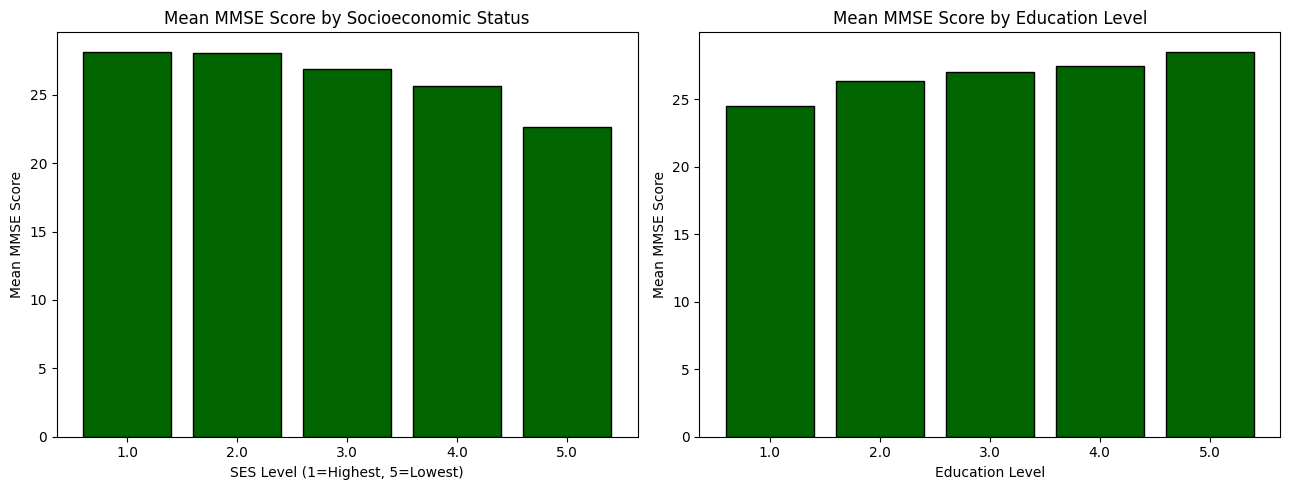

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean MMSE by SES
ses_group = (mri_train_reg_df
             .dropna(subset=['socioeconomic_status'])
             .groupby('socioeconomic_status')['mini_mental_state_examination']
             .mean())
axes[0].bar(ses_group.index.astype(str), ses_group.values, color='darkgreen', edgecolor='black')
axes[0].set_title('Mean MMSE Score by Socioeconomic Status')
axes[0].set_xlabel('SES Level (1=Highest, 5=Lowest)')
axes[0].set_ylabel('Mean MMSE Score')

# Mean MMSE by Education Level
educ_group = (mri_train_reg_df
              .dropna(subset=['education_level'])
              .groupby('education_level')['mini_mental_state_examination']
              .mean())
axes[1].bar(educ_group.index.astype(str), educ_group.values, color='darkgreen', edgecolor='black')
axes[1].set_title('Mean MMSE Score by Education Level')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Mean MMSE Score')

plt.tight_layout();


The results are consistent with the findings from section 4.4. Subjects with lower socioeconomic status (represented by higher SES values) tend to have lower mean MMSE scores on average. For education level, subjects with more years of education generally score higher on the MMSE. These patterns support the interpretation that both socioeconomic status and education level are meaningful predictors of cognitive health, and their relationship with cognitive outcomes appears stable across both target variables.

### 4.8 Brain Volume Metrics by MMSE

Beyond demographic factors, our dataset includes three MRI-derived brain volume measurements: **eTIV** (Estimated Total Intracranial Volume), **nWBV** (Normalized Whole Brain Volume), and **ASF** (Atlas Scaling Factor). These structural measures may capture physical changes associated with cognitive decline. Here we examine their relationship with MMSE scores.

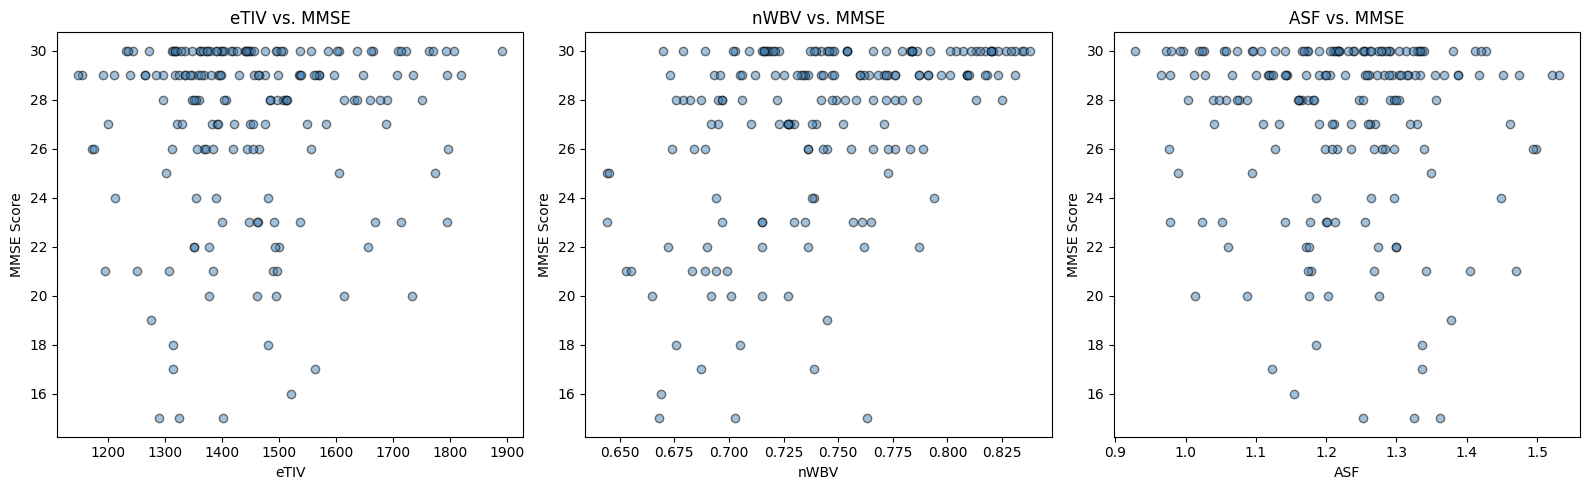

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# eTIV vs MMSE
axes[0].scatter(
    mri_train_reg_df['estimated_total_intracranial_volume'],
    mri_train_reg_df['mini_mental_state_examination'],
    alpha=0.5, color='steelblue', edgecolor='black'
)
axes[0].set_title('eTIV vs. MMSE')
axes[0].set_xlabel('eTIV')
axes[0].set_ylabel('MMSE Score')

# nWBV vs MMSE
axes[1].scatter(
    mri_train_reg_df['normalized_whole_brain_volume'],
    mri_train_reg_df['mini_mental_state_examination'],
    alpha=0.5, color='steelblue', edgecolor='black'
)
axes[1].set_title('nWBV vs. MMSE')
axes[1].set_xlabel('nWBV')
axes[1].set_ylabel('MMSE Score')

# ASF vs MMSE
axes[2].scatter(
    mri_train_reg_df['atlas_scaling_factor'],
    mri_train_reg_df['mini_mental_state_examination'],
    alpha=0.5, color='steelblue', edgecolor='black'
)
axes[2].set_title('ASF vs. MMSE')
axes[2].set_xlabel('ASF')
axes[2].set_ylabel('MMSE Score')

plt.tight_layout();

Among the three brain volume metrics, nWBV shows the most visible positive relationship with MMSE score. Subjects with higher normalized whole brain volume tend to score higher on the cognitive exam, which is consistent with the known association between brain atrophy and dementia progression. The relationships between eTIV and ASF with MMSE appear weaker and less consistent. While these variables may contribute less on their own, they could still prove useful as features when combined with other predictors in the regression model.

---

## 5. ML PLAYGROUND - Regression  (Will become part of the results section)


In this section, we use regression to ...

### 5.1 XXXX

### 5.2 XXXX

### 5.3 XXXX

### 5.XXX Conclusion/Summary


---

## 6. ML PLAYGROUND - Classification (Will become part of the results section)

In this section, we use classification to ...

### 6.1 XXXX

### 6.2 XXXX

### 6.3 XXXX

### 6.XXX Conclusion/Summary

---

## 7. Conclusion

Do not write this section until the final report is due at the end of the semester.  

When you are ready to write the conclusion:

* Summarize your results and what you’ve discovered.
* Indicate what related questions you’d ask in the future if you had time or if you could find the perfect data.
* I expect 2-3 paragraphs, more if needed.